# Predicting 30-Day Hospital Readmission

This notebook develops and evaluates machine-learning models for predicting readmission within 30 days.

To prevent patient-level data leakage, all encounters belonging to one patient are assigned to either the training set or the test set—never both. Preprocessing and model fitting are performed using training data only.

In [48]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [49]:
project_root = Path.cwd()

if not (project_root / "data").exists():
    project_root = project_root.parent

clean_data_path = (
    project_root
    / "data"
    / "processed"
    / "hospital_readmissions_clean.csv"
)

tables_path = project_root / "reports" / "tables"
figures_path = project_root / "reports" / "figures"

tables_path.mkdir(parents=True, exist_ok=True)
figures_path.mkdir(parents=True, exist_ok=True)

encounters = pd.read_csv(clean_data_path, low_memory=False)

print("Encounters:", f"{len(encounters):,}")
print("Unique patients:", f"{encounters['patient_nbr'].nunique():,}")
print(
    "Readmission rate:",
    f"{encounters['readmitted_30d'].mean() * 100:.2f}%"
)

Encounters: 99,340
Unique patients: 69,987
Readmission rate: 11.39%


## Feature exclusions

The following variables are excluded from the predictor matrix:

- `encounter_id`: Arbitrary encounter identifier
- `patient_nbr`: Patient identifier used only for group splitting
- `readmitted`: Original version of the outcome
- `readmitted_30d`: Binary model target
- `diag_1`, `diag_2`, and `diag_3`: Sparse raw ICD-9 codes replaced by broader diagnosis groups
- Numeric admission, discharge, and admission-source IDs: Replaced by readable categorical descriptions

All retained predictors describe information available by the time of discharge. No feature directly contains the subsequent readmission outcome.

In [50]:
excluded_features = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "readmitted_30d",
    "diag_1",
    "diag_2",
    "diag_3",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

feature_columns = [
    column
    for column in encounters.columns
    if column not in excluded_features
]

X = encounters[feature_columns].copy()
y = encounters["readmitted_30d"].copy()
groups = encounters["patient_nbr"].copy()

print("Predictor columns:", X.shape[1])
print("Target observations:", len(y))

Predictor columns: 44
Target observations: 99340


In [51]:
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(
    group_split.split(X, y, groups=groups)
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

groups_train = groups.iloc[train_index].copy()
groups_test = groups.iloc[test_index].copy()

In [52]:
shared_patients = set(groups_train).intersection(set(groups_test))

assert len(shared_patients) == 0
assert len(X_train) + len(X_test) == len(X)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

split_summary = pd.DataFrame({
    "split": ["Training", "Testing"],
    "encounters": [len(X_train), len(X_test)],
    "unique_patients": [
        groups_train.nunique(),
        groups_test.nunique()
    ],
    "readmissions": [
        int(y_train.sum()),
        int(y_test.sum())
    ],
    "readmission_rate_pct": [
        round(y_train.mean() * 100, 2),
        round(y_test.mean() * 100, 2)
    ]
})

split_summary.to_csv(
    tables_path / "patient_level_split_summary.csv",
    index=False
)

print("Shared patients:", len(shared_patients))
split_summary

Shared patients: 0


,split,encounters,unique_patients,readmissions,readmission_rate_pct
0,Training,79567,55989,9070,11.40
1,Testing,19773,13998,2244,11.35


In [53]:
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

categorical_features = [
    column
    for column in feature_columns
    if column not in numeric_features
]

numeric_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "one_hot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 8
Categorical features: 36


## Split validation

The patient-level split produced no overlap between training and testing patients. The 30-day readmission rate was 11.40% in training data and 11.35% in testing data, indicating that the outcome distribution remained well balanced across the two patient groups.

All preprocessing will be embedded inside model pipelines fitted only on the training set. The test set will remain untouched until final model evaluation.

In [54]:
from time import perf_counter

import joblib

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [55]:
dummy_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        DummyClassifier(
            strategy="prior"
        )
    )
])

logistic_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            random_state=42
        )
    )
])

random_forest_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=10,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=42
        )
    )
])

models = {
    "Dummy classifier": dummy_pipeline,
    "Logistic regression": logistic_pipeline,
    "Random forest": random_forest_pipeline
}

In [56]:
training_times = {}
trained_models = {}

for model_name, model_pipeline in models.items():
    print(f"Training {model_name}...")

    start_time = perf_counter()

    model_pipeline.fit(X_train, y_train)

    elapsed_time = perf_counter() - start_time

    training_times[model_name] = elapsed_time
    trained_models[model_name] = model_pipeline

    print(
        f"Completed {model_name} in "
        f"{elapsed_time:.2f} seconds.\n"
    )

Training Dummy classifier...
Completed Dummy classifier in 0.71 seconds.

Training Logistic regression...
Completed Logistic regression in 4.54 seconds.

Training Random forest...
Completed Random forest in 13.02 seconds.



In [57]:
training_summary = pd.DataFrame({
    "model": list(training_times.keys()),
    "training_time_seconds": [
        round(value, 2)
        for value in training_times.values()
    ]
})

training_summary.to_csv(
    tables_path / "model_training_times.csv",
    index=False
)

training_summary

,model,training_time_seconds
0,Dummy classifier,0.71
1,Logistic regression,4.54
2,Random forest,13.02


In [58]:
models_path = project_root / "models"
models_path.mkdir(parents=True, exist_ok=True)

model_filenames = {
    "Dummy classifier": "dummy_classifier.joblib",
    "Logistic regression": "logistic_regression.joblib",
    "Random forest": "random_forest.joblib"
}

for model_name, filename in model_filenames.items():
    output_path = models_path / filename

    joblib.dump(
        trained_models[model_name],
        output_path
    )

    print(f"Saved {model_name}: {output_path}")

Saved Dummy classifier: c:\Users\ezont\Desktop\PersonalProj\hospital_readmission_prediction\models\dummy_classifier.joblib
Saved Logistic regression: c:\Users\ezont\Desktop\PersonalProj\hospital_readmission_prediction\models\logistic_regression.joblib
Saved Random forest: c:\Users\ezont\Desktop\PersonalProj\hospital_readmission_prediction\models\random_forest.joblib


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay

VILLANOVA_NAVY = "#00205B"
LIGHT_BLUE = "#5BC2E7"
GRAY = "#6B7280"

sns.set_theme(style="whitegrid")

In [60]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [61]:
models_path = project_root / "models"

evaluated_models = {
    "Dummy classifier": joblib.load(
        models_path / "dummy_classifier.joblib"
    ),
    "Logistic regression": joblib.load(
        models_path / "logistic_regression.joblib"
    ),
    "Random forest": joblib.load(
        models_path / "random_forest.joblib"
    )
}

print("Loaded models:", list(evaluated_models.keys()))

Loaded models: ['Dummy classifier', 'Logistic regression', 'Random forest']


In [62]:
def calculate_metrics(
    model_name,
    y_true,
    predicted_probability,
    threshold=0.50
):
    predicted_class = (
        predicted_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predicted_class
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(
            y_true,
            predicted_probability
        ),
        "pr_auc": average_precision_score(
            y_true,
            predicted_probability
        ),
        "precision": precision_score(
            y_true,
            predicted_class,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            predicted_class,
            zero_division=0
        ),
        "specificity": specificity,
        "f1": f1_score(
            y_true,
            predicted_class,
            zero_division=0
        ),
        "brier_score": brier_score_loss(
            y_true,
            predicted_probability
        ),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    }

In [63]:
predicted_probabilities = {}
evaluation_records = []

for model_name, model in evaluated_models.items():
    probabilities = model.predict_proba(X_test)[:, 1]

    predicted_probabilities[model_name] = probabilities

    evaluation_records.append(
        calculate_metrics(
            model_name,
            y_test,
            probabilities,
            threshold=0.50
        )
    )

evaluation_results = pd.DataFrame(evaluation_records)

metric_columns = [
    "model",
    "roc_auc",
    "pr_auc",
    "precision",
    "recall",
    "specificity",
    "f1",
    "brier_score"
]

evaluation_results[metric_columns].round(3)

,model,roc_auc,pr_auc,precision,recall,specificity,f1,brier_score
0,Dummy classifier,0.500,0.113,0.000,0.000,1.000,0.000,0.101
1,Logistic regression,0.669,0.225,0.547,0.018,0.998,0.035,0.096
2,Random forest,0.675,0.222,0.192,0.550,0.703,0.284,0.215


In [64]:
evaluation_results.to_csv(
    tables_path / "model_evaluation_default_threshold.csv",
    index=False
)

evaluation_results.round(4)

,model,threshold,roc_auc,pr_auc,precision,recall,specificity,f1,brier_score,true_negatives,false_positives,false_negatives,true_positives
0,Dummy classifier,0.5,0.5000,0.1135,0.0000,0.0000,1.0000,0.0000,0.1006,17529,0,2244,0
1,Logistic regression,0.5,0.6689,0.2249,0.5467,0.0183,0.9981,0.0354,0.0960,17495,34,2203,41
2,Random forest,0.5,0.6751,0.2217,0.1917,0.5499,0.7032,0.2843,0.2149,12326,5203,1010,1234


In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

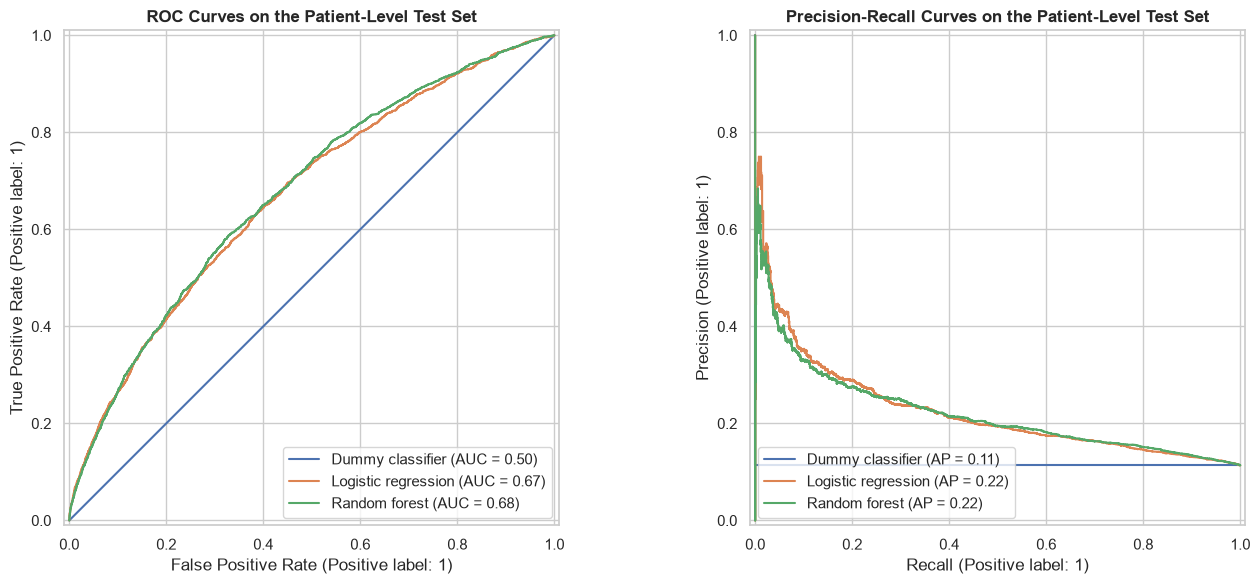

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for model_name, probabilities in predicted_probabilities.items():
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities,
        name=model_name,
        ax=axes[0]
    )

    PrecisionRecallDisplay.from_predictions(
        y_test,
        probabilities,
        name=model_name,
        ax=axes[1]
    )

axes[0].set_title(
    "ROC Curves on the Patient-Level Test Set",
    fontweight="bold"
)
axes[1].set_title(
    "Precision-Recall Curves on the Patient-Level Test Set",
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    figures_path / "roc_and_precision_recall_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
thresholds = [0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
threshold_records = []

for model_name in [
    "Logistic regression",
    "Random forest"
]:
    probabilities = predicted_probabilities[model_name]

    for threshold in thresholds:
        threshold_records.append(
            calculate_metrics(
                model_name,
                y_test,
                probabilities,
                threshold=threshold
            )
        )

threshold_results = pd.DataFrame(threshold_records)

threshold_results.to_csv(
    tables_path / "model_threshold_comparison.csv",
    index=False
)

threshold_results[
    [
        "model",
        "threshold",
        "precision",
        "recall",
        "specificity",
        "f1"
    ]
].round(3)

,model,threshold,precision,recall,specificity,f1
0,Logistic regression,0.10,0.167,0.660,0.579,0.267
1,Logistic regression,0.15,0.232,0.346,0.854,0.278
2,Logistic regression,0.20,0.287,0.205,0.935,0.239
3,Logistic regression,0.30,0.389,0.078,0.984,0.131
4,Logistic regression,0.40,0.469,0.037,0.995,0.068
5,Logistic regression,0.50,0.547,0.018,0.998,0.035
6,Random forest,0.10,0.113,1.000,0.000,0.204
7,Random forest,0.15,0.113,1.000,0.000,0.204
8,Random forest,0.20,0.113,1.000,0.000,0.204
9,Random forest,0.30,0.116,0.995,0.025,0.207


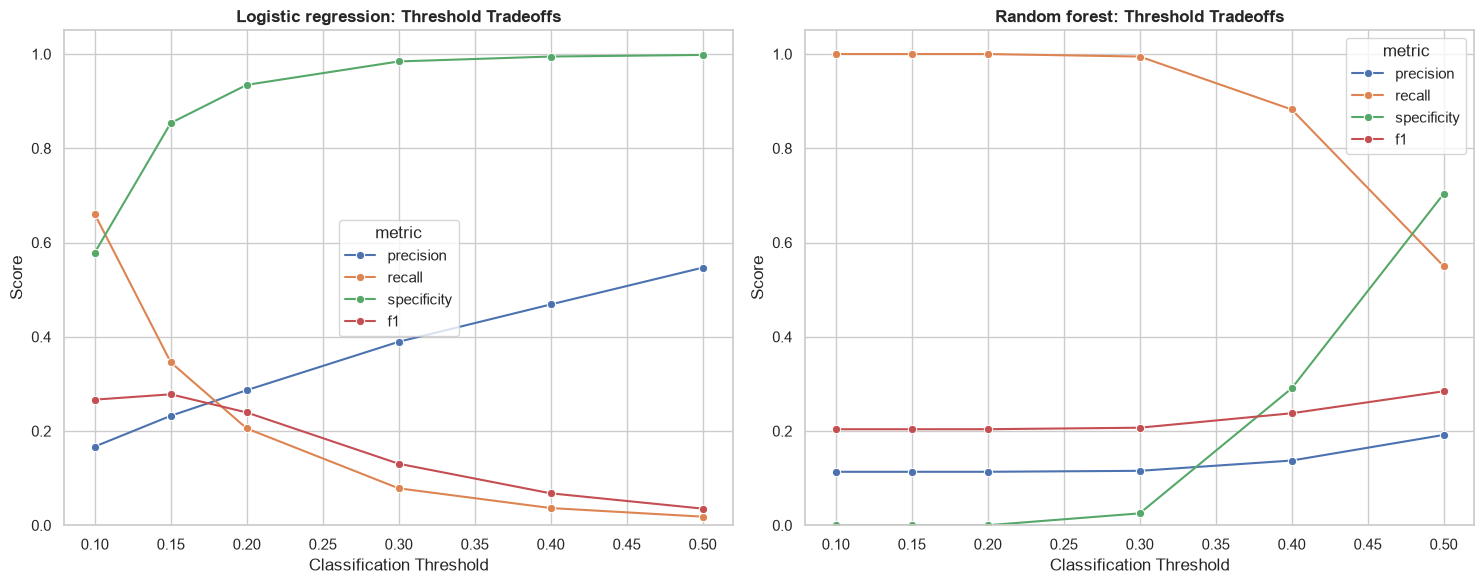

In [68]:
threshold_plot_data = threshold_results.melt(
    id_vars=["model", "threshold"],
    value_vars=["precision", "recall", "specificity", "f1"],
    var_name="metric",
    value_name="score"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, model_name in zip(
    axes,
    ["Logistic regression", "Random forest"]
):
    model_data = threshold_plot_data[
        threshold_plot_data["model"] == model_name
    ]

    sns.lineplot(
        data=model_data,
        x="threshold",
        y="score",
        hue="metric",
        marker="o",
        ax=ax
    )

    ax.set_title(
        f"{model_name}: Threshold Tradeoffs",
        fontweight="bold"
    )
    ax.set_xlabel("Classification Threshold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)

plt.tight_layout()

plt.savefig(
    figures_path / "threshold_tradeoffs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model-evaluation findings

At the default 0.50 classification threshold:

- The dummy classifier had no ability to distinguish encounters resulting in readmission from those that did not.
- Logistic regression achieved a ROC-AUC of 0.669 and the highest PR-AUC of 0.225. Its Brier score of 0.096 indicated better probability accuracy than the random forest. However, the default threshold identified only 41 of 2,244 readmissions, producing 1.8% recall.
- The random forest achieved the highest ROC-AUC at 0.675. It identified 1,234 of 2,244 readmissions, producing 55.0% recall, but also incorrectly flagged 5,203 encounters. Its precision was 19.2%.
- Both trained models substantially exceeded the dummy classifier's PR-AUC of 0.113, although overall discrimination remained moderate.

The threshold analysis demonstrates that classification performance depends on the relative consequences of false negatives and false positives:

- At a 0.10 threshold, logistic-regression recall increased to 66.0%, while precision decreased to 16.7%.
- Logistic regression achieved its highest displayed F1 score of 0.278 at a 0.15 threshold.
- The random forest achieved its highest displayed F1 score of 0.284 at its default 0.50 threshold.
- Random-forest thresholds below 0.30 classified nearly every encounter as positive because class weighting shifted its predicted probabilities upward.

These thresholds are presented as a sensitivity analysis rather than optimized clinical cutoffs. Selecting an operating threshold for actual use would require external validation, explicit consideration of intervention capacity, and clinical input regarding the relative costs of missed readmissions and unnecessary follow-up.

Neither model is suitable for clinical deployment. The results demonstrate a historical, educational machine-learning workflow rather than a validated clinical decision system.